## LAB ON THE DFT

In this lab, we are going to familiarize ourselves with the Discrete Fourier Transform (DFT) and understand why it is useful in signal processing. We will use the Discrete Fourier Transform (DFT) of a discrete signal f:

$$
X[k] = \sum_{n=0}^{N-1} f[n] e^{-i \frac{2\pi}{N} k n}
$$

This is called the Discrete Fourier Transform (DFT). The inverse operation is used to retrieve the signal:

$$
f[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] e^{i \frac{2\pi}{N} k n}
$$

As presented from the class the DFT output X[k] is a different representation of the signal f, its frequency representation.

# Warmup: Implement the DFT
It is easy to implement a DFT algorithm. You can do it in the cell below.

However our implementation is not efficient, and for this reason it's much better to use version from packages, as for example numpy. These packages use a much more complex algoritmich implementation of the DFT, but also much more efficient named FFT algorithm.

NB: the keyword for the imaginary number i in python is j.

In [1]:
import numpy as np

def dft(signal):
    """
    Compute the Discrete Fourier Transform (DFT) of a 1D signal using a double loop.

    Args:
        signal (list or np.array): Input signal (real or complex)

    Returns:
        np.array: DFT output (complex numbers)
    """
    N = len(signal)
    output = np.zeros(N, dtype=complex)  # Initialize an array for the output

    for k in range(N):  # Loop over output frequencies
        sum_value = 0
        for n in range(N):  # Loop over input signalj
            angle = 2*np.pi/N*k*n # COMPLETE HERE
            sum_value += signal[n]*pow(np.e, -(1j)*angle) # COMPLETE HERE
        output[k] = sum_value  # Store the computed frequency component

    return output

def idft(freq_signal):
    """
    Compute the Inverse Discrete Fourier Transform (IDFT) using a double loop.

    Args:
        freq_signal (list or np.array): Frequency domain signal (complex numbers)

    Returns:
        np.array: Reconstructed time-domain signal (complex numbers)
    """
    N = len(freq_signal)
    output = np.zeros(N, dtype=complex)  # Initialize an array for the output

    for n in range(N):  # Loop over time samples
        sum_value = 0
        for k in range(N):  # Loop over frequency components
            angle = 2*np.pi/N*k*n # COMPLETE HERE
            sum_value += freq_signal[k]*pow(np.e, 1j*angle) # COMPLETE HERE
        output[n] = sum_value / N  # Normalize by N (important for inverse)

    return output

In [2]:
# Example usage
signal = np.array([1, 2, 3, 4])  # Simple input signal

# Compute DFT
dft_result = dft(signal)

# Compute IDFT
reconstructed_signal = idft(dft_result)

# Check if reconstruction is correct
if np.array_equal(signal, np.round(reconstructed_signal.real, 4)):
    print("✅ Implementation is correct: The reconstructed signal matches the original.")
else:
    print("❌ Implementation is NOT correct: The reconstructed signal does not match the original.")


✅ Implementation is correct: The reconstructed signal matches the original.


# Using FFT from Packages

From now on, you should only use DFT implementations from existing packages.  

To compute the Fourier coefficients, you can use the following function on your signal:

```python
coefficients = np.fft.fft(signal)
```
To compute the associated frequencies, use:
```python
frequencies = np.fft.fftfreq(len(signal), d=1/fs) % fs is the sampling frequency of the signal
```
For other functions you can either ask chatgpt or check the documentation of numpy.

# Exercise 1: Denoising a signal using the DFT:
As you have seen in your lecture the DFT is able to extract the frequencies from a signal. In this exercise we will see how this could be used to remove noise from a signal.
1. First we generate a periodic signal made of three sinusoidal waves
2. then we add some noise to it
3. Your goal is to use the DFT to retrieve the clean signal from the noisy signal. In This exercise we will not use our implementation but the efficient implementation from numpy.

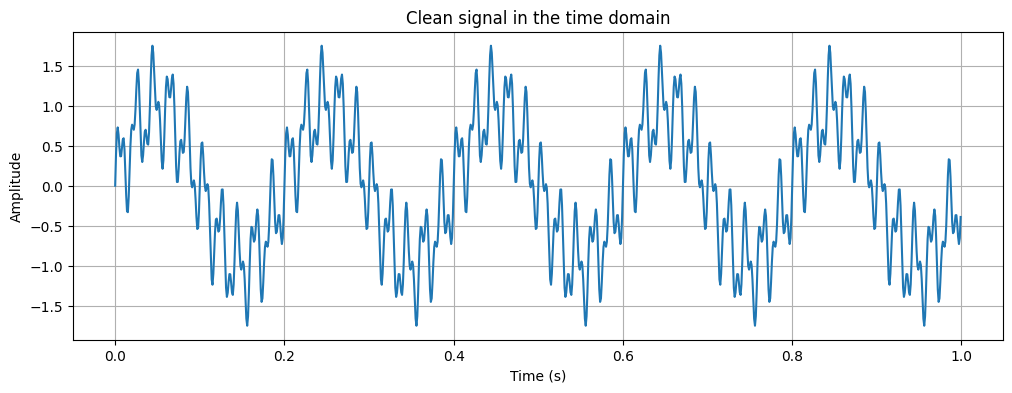

In [3]:
# 1. CREATE A SIGNAL USING THREE SINUSOIDAL
import numpy as np
import matplotlib.pyplot as plt

# Create a time domain signal composed of three sinusoidal components
fs = 1000  # Sampling frequency in Hz
t = np.arange(0, 1, 1/fs)  # Time vector from 0 to 1 second

# Sinusoidal signals with different frequencies and amplitudes
f1, f2, f3 = 5, 50, 120  # Frequencies in Hz
A1, A2, A3 = 1.0, 0.5, 0.3  # Amplitudes

# Composite signal
signal = A1 * np.sin(2 * np.pi * f1 * t) + \
         A2 * np.sin(2 * np.pi * f2 * t) + \
         A3 * np.sin(2 * np.pi * f3 * t)

# Plot the time domain signal
plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Clean signal in the time domain")
plt.grid()
plt.show()

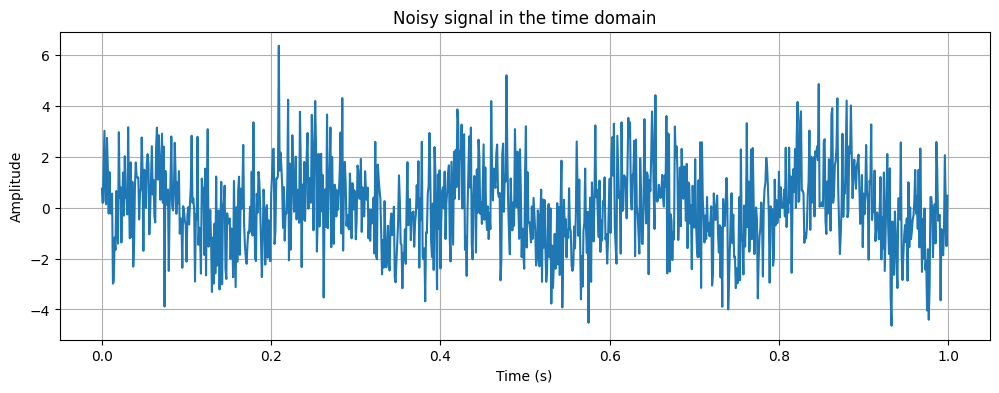

In [4]:
# 2. ADD some noise to the signal
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # Set a fixed seed for reproducibility

# Create a time domain signal composed of three sinusoidal components
fs = 1000  # Sampling frequency in Hz
t = np.arange(0, 1, 1/fs)  # Time vector from 0 to 1 second

noise = np.random.normal(0, 1.5, signal.shape)
# Composite signal
noisy_signal = signal + noise

# Plot the time domain signal
plt.figure(figsize=(12, 4))
plt.plot(t, noisy_signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Noisy signal in the time domain")
plt.grid()
plt.show()

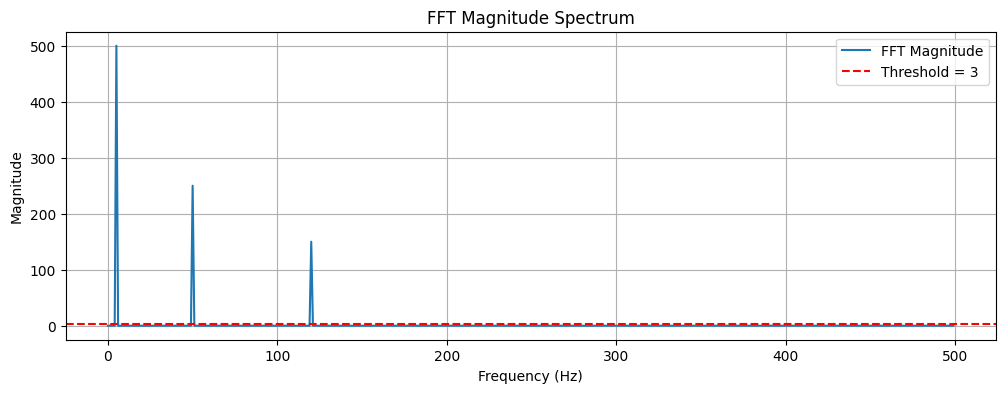

/home/zb/Main/VALAIS/ANNO2/SEM4/Signal/SigInf_2026/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/zb/Main/VALAIS/ANNO2/SEM4/Signal/SigInf_2026/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


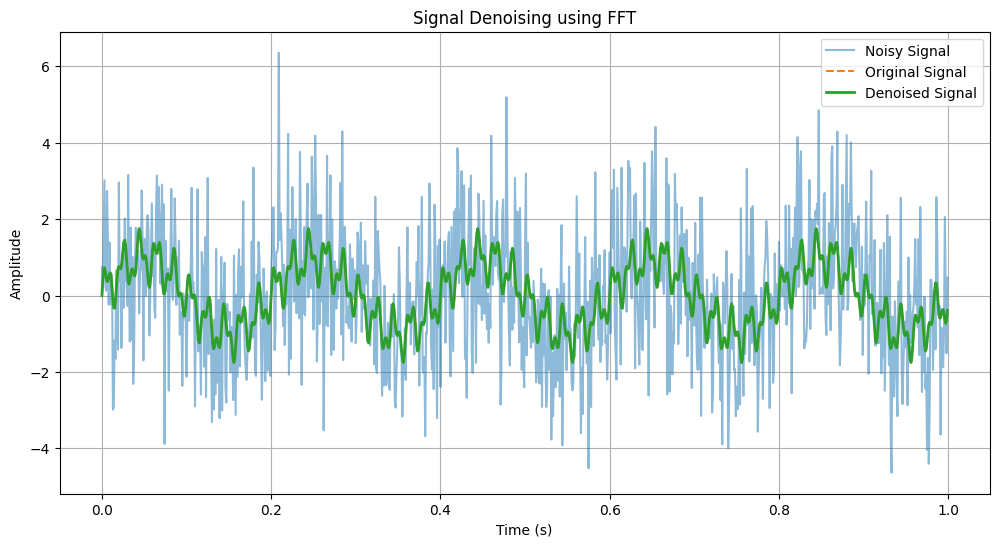

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the FFT
fft_coeffs = np.fft.fft(signal) # COMPLETE HERE: COMPUTE THE FFT COEFFICIENTS OF THE NOISY SIGNAL
frequencies = np.fft.fftfreq(len(signal), d=1/fs) % fs # COMPLETE HERE: COMPUTE THE FREQUENCIES CORRESPONDING TO THE FFT COEFFICIENTS

# Define threshold
threshold = 3 # ADJUST HERE: CHOSE A VALUE AFTER PLOTTING THE FFT COEFFICIENT vs. FREQUENCIES

# Visualize the FFT magnitudes with a horizontal threshold line
plt.figure(figsize=(12, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(fft_coeffs)[:len(frequencies)//2], label="FFT Magnitude")
plt.axhline(y=threshold, color='r', linestyle='--', label=f"Threshold = {threshold}")  # Horizontal line
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Magnitude Spectrum")
plt.legend()
plt.grid()
plt.show()

# Apply thresholding (keep only strong frequency components)
fft_coeffs_filtered = np.where(np.abs(fft_coeffs) > threshold, fft_coeffs, 0)

# Compute the inverse FFT
denoised_signal = np.fft.ifft(fft_coeffs_filtered) # COMPLETE HERE: COMPUTE THE INVERSE FOURIER TRANSFORM AND TAKE ITS REAL PART

# Plot original, noisy, and denoised signals
plt.figure(figsize=(12, 6))
plt.plot(t, noisy_signal, alpha=0.5, label="Noisy Signal")
plt.plot(t, signal, label="Original Signal", linestyle="dashed")
plt.plot(t, denoised_signal, label="Denoised Signal", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal Denoising using FFT")
plt.legend()
plt.grid()
plt.show()


In [6]:
import numpy as np

# Compute the Mean Squared Error (MSE) to measure the difference
mse = np.mean((signal - denoised_signal.real) ** 2)

# Check if the signals are close within a small tolerance
if mse < np.abs(signal).mean()/100:
    print(f"✅ The denoising was successfull and the reconstructed signal is accurate within tolerance (MSE = {mse:.6f}).")
else:
    print(f"❌ The reconstruction deviates from the original (MSE = {mse:.6f}).")


✅ The denoising was successfull and the reconstructed signal is accurate within tolerance (MSE = 0.000000).


# Exercise 2: 2D FFT of an image
The goal of this exercise is to explore spatial frequencies using the 2D Fast Fourier Transform (FFT). We will work with an MRI image the focus of our research lab. Take a second to imagine why can we apply discrete fourier transform in the case of an image. Before reading the rest of the exercise plese try to guess what frequencies could represent here.

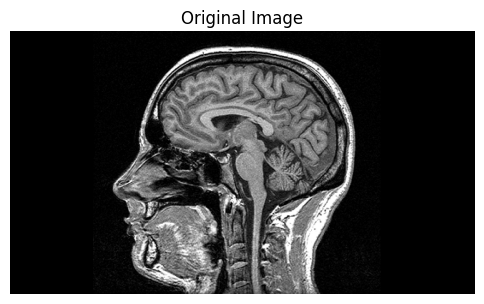

(367, 650, 4)


In [7]:
# prompt: load image in numpy array from url: "https://drive.google.com/file/d/1lrVvIl-bxyE8PpFnehHQTg3R7L6WPshf/view?usp=share_link"

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def download_image_from_url(url):
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad status codes
    image = Image.open(BytesIO(response.content))
    return np.array(image)
# Load a sample image (replace 'sample_image.png' with your MRI image)
image_url = "https://drive.google.com/uc?id=1f5jXB810G3FiPSk2kfv10CYgyBue4Irk"
image = download_image_from_url(image_url)
# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

print(image.shape)

It seems there is something weird happened with the image format. For the fft of a gray scale image, and for the rest of the lab we would need the image to be 2D, hence a numpy array of size (367, 650) with the values beeing the intensity of gray. 

Your task it to explore the array and understand how to correctly reformat the image to the expected array.

(367, 650)
✅ Image size is correct. Image below should look like a brain MRI


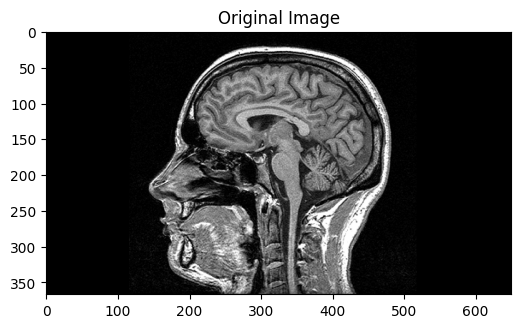

In [8]:
new_image = np.zeros((367, 650)) ## COMPLETE HERE
for i in range(len(image)):
    for j in range(len(image[0])):
        new_image[i][j] = image[i][j][0]

image = new_image
print(image.shape)
 

if image.shape == (367, 650):
    print(f"✅ Image size is correct. Image below should look like a brain MRI")
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
else:
    print(f"❌ Image size is wrong")

Just as sound is composed of waves that oscillate in time, spatial textures exhibit oscillations in space. In this context, spatial position plays a role analogous to time in temporal signals. Since images are two-dimensional, they contain frequency components along both the x and y axes. Therefore, any image can be considered as a sum of 2D sinusoids. In the same way that the FFT extracts temporal frequencies from a signal, it can also extract the 2D sinusoidal components that combine to form the final image.

In this exercise we will do the following experiment:    
1. Take the image compute the DFT coefficient and have a look at what actual coefficients of a real image looks like
2. Reconstruct the image correponding to different part of the coefficients
3. Observe which information is  coming from where in the frequency domain
4. Combine all the partial reconstructed images

Note that the expression for the For 2D discrete signals, like images, the function becomes $f(x, y) $, where $ f(x, y) $ represents the pixel intensity at position $ (x, y) $. The 2D DFT is given by:

$$
F(u, v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x, y) e^{-i 2 \pi \left( \frac{u x}{M} + \frac{v y}{N} \right)}
$$

where:
- $ M $ and $ N $ are the dimensions of the image.
- $ F(u, v) $ is the frequency domain representation.

In [9]:
import scipy.fftpack
from scipy.fftpack import fft2, fftshift, fftfreq
import plotly.graph_objs as go

d = 1
# Compute the 2D FFT and shift the zero-frequency component to the center
fft_image = fft2(image)
fft_image_shifted = fftshift(fft_image)

# Compute the magnitude spectrum
magnitude_spectrum = np.abs(fft_image_shifted)

# Image dimensions
M, N = image.shape
d = 1  # 1 pixel = 1 mm

# Compute real spatial frequency axes (fftshift puts the k space center in the center of the image)
freq_y = fftshift(fftfreq(M, d=d))  # Frequency axis for y (1/mm)
freq_x = fftshift(fftfreq(N, d=d))  # Frequency axis for x (1/mm)

# Create a meshgrid for 2D frequencies
FREQ_X, FREQ_Y = np.meshgrid(freq_x, freq_y)

# Create the 3D interactive plot using real spatial frequencies
fig = go.Figure(data=[go.Surface(z=np.log(magnitude_spectrum + 1), x=FREQ_X, y=FREQ_Y, colorscale='Viridis')])

# Add distance thresholds as circles (now using real frequencies)
thresholds = [0.1, 0.2, 0.4]  # These should be adjusted based on frequency units
center_freq_y, center_freq_x = 0, 0  # In frequency space, the center is at (0,0)

# Function to generate circle points in frequency space
def generate_circle_points(center_x, center_y, radius, num_points=100):
    angles = np.linspace(0, 2 * np.pi, num_points)
    circle_x = center_x + radius * np.cos(angles)
    circle_y = center_y + radius * np.sin(angles)
    return circle_x, circle_y

# Add each threshold circle to the plot
for radius in thresholds:
    circle_x, circle_y = generate_circle_points(center_freq_x, center_freq_y, radius)
    fig.add_trace(go.Scatter3d(
        x=circle_x,
        y=circle_y,
        z=np.full_like(circle_x, 13),  # Positioned at average height + offset
        mode='lines',
        line=dict(color='red', width=2),
        name=f'Radius {radius}'
    ))

# Update layout for better visualization
fig.update_layout(
    title='Interactive 3D Plot of K-space (Frequency Domain) with Real Frequencies',
    scene=dict(
        xaxis_title='Frequency X (1/mm)',
        yaxis_title='Frequency Y (1/mm)',
        zaxis_title='Log Magnitude'
    ),
    margin=dict(l=65, r=50, b=65, t=90)
)

# Show the interactive plot
fig.show()

Note that the center of the k-space contains the highest coefficients, soo much that a logscale was used for visualization, meaning that those frequency are the ones that are mostly contributing to the final image. You can choose some different radious for the red circles that correspond to a partitionning of the k-space, that we will reconstruct separately in the next cell. This way you can see which regions of the k-space contain which information.

Reconstructing Group 4: 100%|██████████| 118641/118641 [00:00<00:00, 928633.13it/s]


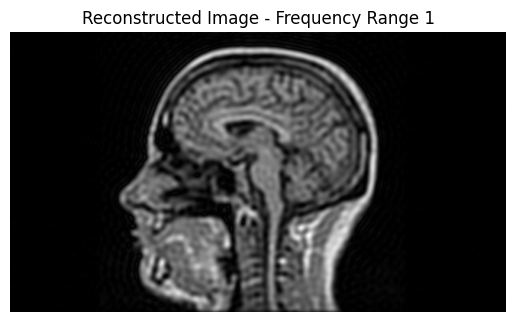

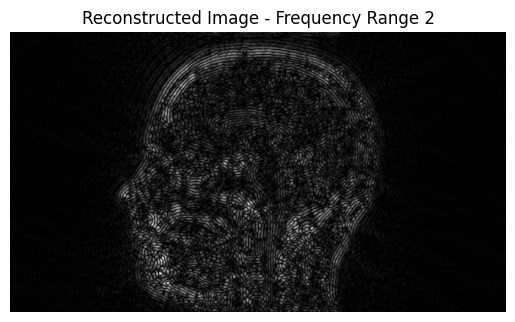

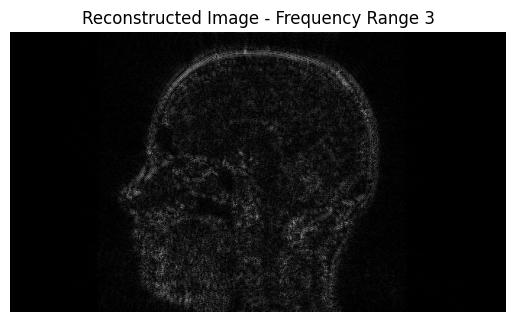

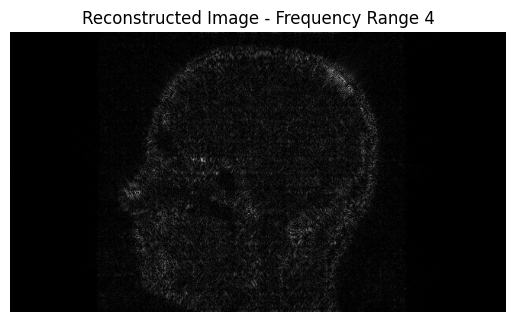

In [10]:
from tqdm import tqdm  # Import tqdm for the progress bar

# Compute distances in frequency space
frequency_distances = np.sqrt(FREQ_X**2 + FREQ_Y**2)

# Flatten the distances and get sorted indices
distances_flat = frequency_distances.flatten()
sorted_indices = np.argsort(distances_flat)

# Define frequency-based distance thresholds (in 1/mm)
thresholds = [0, 0.1, 0.2, 0.4, np.max(distances_flat)]  # Adjust as needed

# Split the indices into groups based on thresholds
split_indices = []
for i in range(len(thresholds) - 1):
    mask = (distances_flat >= thresholds[i]) & (distances_flat < thresholds[i + 1])
    split_indices.append(np.where(mask)[0])

# Prepare empty images for the four reconstructions
reconstructed_images = [np.zeros((M, N), dtype=np.complex128) for _ in range(4)]

# Reconstruct images using only the Fourier coefficients from each frequency range
for group_index, indices in enumerate(split_indices):
    for index in tqdm(indices, desc=f"Reconstructing Group {group_index + 1}"):
        # Convert the flattened index into 2D coordinates
        u, v = np.unravel_index(index, (M, N))

        # Retain only the selected frequency components
        reconstructed_images[group_index][u, v] = fft_image_shifted[u, v]

# Perform the inverse FFT to reconstruct images
for i, reconstructed_image in enumerate(reconstructed_images):
    reconstructed_spatial = np.fft.ifft2(np.fft.ifftshift(reconstructed_image))  # Inverse FFT
    reconstructed_images[i] = reconstructed_spatial
    plt.imshow(np.abs(reconstructed_spatial), cmap='gray')
    plt.title(f'Reconstructed Image - Frequency Range {i + 1}')
    plt.axis('off')
    plt.show()

You can observe that the coefficients near the k space center (low frequencies) are more responsible for the slowly changing patterns, such as the average values and smooth transitions. On the other hand, increasing frequencies are more responsible for the sharper details, such as edges.

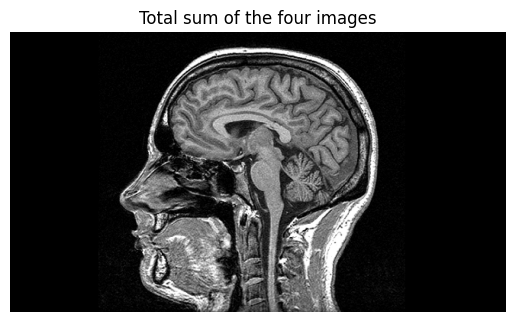

In [11]:
# Plot the four reconstructed images
totimage = sum(reconstructed_images)

plt.imshow(np.abs(totimage), cmap='gray')
plt.title(f'Total sum of the four images')
plt.axis('off')
plt.show()

Taking the sum of the images yields the good reconstructed image. Why is it the case?

# Exercise 3: Why the DFT extracts the frequencies?

We have seen in exercises 1 and 2 that the DFT is able to extract frequencies like this:
$$
X[k] = \sum_{n=0}^{N-1} f[n] e^{-i \frac{2\pi}{N} k n}
$$
but how can we understand it intuitively?

### 1.Understanding the DFT as Vector Dot Products

We can express the DFT as a dot product between two vectors:

1. **Signal Vector**: We can represent the discrete signal $ f[n] $ as:

   $$
   \mathbf{f} = \begin{bmatrix} f[0] & f[1] & \dots & f[N-1] \end{bmatrix}
   $$

2. **Complex Exponential Vector**: The complex exponential $ e^{-i \frac{2\pi}{N} k n} $ for a fixed $ k $ can be represented as:

   $$
   \mathbf{e_k} = \begin{bmatrix} e^{-i \frac{2\pi}{N} k \cdot 0} & e^{-i \frac{2\pi}{N} k \cdot 1} & \dots & e^{-i \frac{2\pi}{N} k \cdot (N-1)} \end{bmatrix}
   $$

Now, we can write the DFT $ X[k] $ as:

$$
X[k] = \mathbf{f} \cdot \mathbf{e_k} = \begin{bmatrix} f[0] & f[1] & \dots & f[N-1] \end{bmatrix} \cdot \begin{bmatrix} e^{-i \frac{2\pi}{N} k \cdot 0} \\ e^{-i \frac{2\pi}{N} k \cdot 1} \\ \vdots \\ e^{-i \frac{2\pi}{N} k \cdot (N-1)} \end{bmatrix}
$$

Expanding this, we have:

$$
X[k] = f[0] \cdot e^{-i \frac{2\pi}{N} k \cdot 0} + f[1] \cdot e^{-i \frac{2\pi}{N} k \cdot 1} + \dots + f[N-1] \cdot e^{-i \frac{2\pi}{N} k \cdot (N-1)}
$$


### 2.What is $ e^{-i2\pi kn/N} $?
This expression seems really complex but we can use Euler's formula to get a more intuitive understanding:
$$
e^{-i2\pi kn/N} = cos(-2\pi kn/N) + i*sin(-2\pi kn/N)
$$

This means that we are doing the dot product between the signal f and a vector that is composed by real and complex sinusoidal signals. As you can see the frequency of the sinusoidal signal is 1/k and the signal is sampled in several different location from (1/N) to (N-1)/N. Let us now visualize that better:


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, ToggleButton

# Fix N to 15
N = 15

def plot_euler_visualization(k, n, show_all):
    # Create figure for the sine and cosine waves
    fig, ax = plt.subplots(figsize=(8, 5))

    # Define the range of t to correctly display discrete n values
    t = np.linspace(0, N - 1, 1000)  # Adjusted to cover all possible n values

    # Compute the sine and cosine waves
    cos_wave = np.cos(-2 * np.pi * k * t / N)  # Cosine wave (real part)
    sin_wave = np.sin(-2 * np.pi * k * t / N)  # Sine wave (imaginary part)

    # Plot the sinusoidal functions
    ax.plot(t, cos_wave, label='Cosine (Real Part)', color='red')
    ax.plot(t, sin_wave, label='Sine (Imaginary Part)', color='blue')

    if show_all:
        # Highlight all discrete points n for the given k
        for n_value in range(N):
            ax.scatter(n_value, np.cos(-2 * np.pi * k * n_value / N), color='red', s=50, alpha=0.6)
            ax.scatter(n_value, np.sin(-2 * np.pi * k * n_value / N), color='blue', s=50, alpha=0.6)
    else:
        # Highlight only the selected discrete point n
        ax.scatter(n, np.cos(-2 * np.pi * k * n / N), color='red', s=100, zorder=5)
        ax.scatter(n, np.sin(-2 * np.pi * k * n / N), color='blue', s=100, zorder=5)

    ax.set_title(f"Cosine and Sine Waves for k={k}")
    ax.set_xlabel("n (Time index)")
    ax.set_ylabel("Amplitude")
    ax.legend()
    ax.grid(True)

    # Display the plot
    plt.show()

# Create interactive sliders for k and n, and a toggle button to show all points
interact(plot_euler_visualization,
         k=IntSlider(min=0, max=N-1, step=1, value=0),
         n=IntSlider(min=0, max=N-1, step=1, value=0),
         show_all=ToggleButton(value=False, description='Show All Points'))

interactive(children=(IntSlider(value=0, description='k', max=14), IntSlider(value=0, description='n', max=14)…

<function __main__.plot_euler_visualization(k, n, show_all)>

# Why are we extracting the frequencies?
## The dot product as a form of similarity
The dot product of two vectors a and b
$$
a \cdot b = |a|*|b|*cos(\alpha)
$$
where $\alpha$ is the angle between a and b. We can interprete this as multilplying the norm of f with the projection of $e_k$ on f.

![Dot Product Similarity](https://drive.google.com/uc?id=1lrVvIl-bxyE8PpFnehHQTg3R7L6WPshf)


The key message is that we are looking at how similar f is to some sinuisoidal signal with a frequency that is linked to k. This is an intuitive reason behind why the k-th coefficient of X, is extracting how much of the frequency k is contained into the original signal f.